# CS729 Question 4: Membership Inference Attack (MIA)

In this notebook, we empirically study a simple **loss-based Membership Inference Attack (MIA)** on the MNIST dataset using a feed-forward neural network.

A Membership Inference Attack aims to determine whether a given sample was part of the model's training data. In this question, we compare a **non-private model trained with SGD** and a **private model trained with DP-SGD** under the same attack pipeline. The assignment requires splitting the dataset into two disjoint parts, computing per-sample cross-entropy losses on both parts, applying a threshold-based attacker, and reporting confusion matrices, ROC curves, and AUC values. 

We use the following notation:

- $D_{\mathrm{in}}$: member dataset, i.e., samples used for training
- $D_{\mathrm{out}}$: non-member dataset, i.e., holdout samples not used during training

For a sample-label pair $(x, y)$, the attack uses the **per-sample cross-entropy loss**

$$
L(x, y) = -\log p_\theta(y \mid x),
$$

where $p_\theta(y \mid x)$ is the predicted probability assigned by the model to the true class $y$.

The attacker predicts membership using the threshold rule

$$
\hat{m}(x) =
\begin{cases}
1, & \text{if } L(x) < \tau, \\
0, & \text{otherwise},
\end{cases}
$$

where $\hat{m}(x)=1$ denotes **Member** and $\hat{m}(x)=0$ denotes **Not-Member**. Thus, smaller loss values are interpreted as stronger evidence that the sample was present in the training data. This is exactly the loss-based attack structure required in the assignment. 

*Both models use the same architecture, optimizer family (SGD-based), batch size, and training duration; the only difference is the privacy mechanism in DP-SGD.*

In [1]:
!pip install -q opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 6.6 MB/s eta 0:00:00ta 0:00:01


In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

from opacus import PrivacyEngine
from opacus.accountants.utils import get_noise_multiplier

from IPython.display import display

## Experimental Setup

We use the same basic setup as in the earlier questions:

- Dataset: MNIST
- Model: feed-forward neural network
- Optimizer: SGD
- Private optimizer: DP-SGD via Opacus
- Accountant for DP-SGD: RDP
- Privacy target for the private model: ($\epsilon = 5$, $\delta = 10^{-5}$\)

Since Question 4 does not explicitly fix $\epsilon$, we choose $\epsilon = 5$ for the private model for consistency with the earlier experiments.

In [3]:
SEED = 42

BATCH_SIZE = 64
EVAL_BATCH_SIZE = 1024
EPOCHS_NONPRIVATE = 10
EPOCHS_PRIVATE = 10

LR = 0.1
MOMENTUM = 0.0

DELTA = 1e-5
TARGET_EPSILON = 5.0
ACCOUNTANT = "rdp"
MAX_GRAD_NORM = 1.0

DIN_FRACTION = 0.5   # 30,000 for Din and 30,000 for Dout from MNIST train set

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [4]:
def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

## Data Loading and Split into `Din` / `Dout`

We use the standard MNIST training split and partition it into two **disjoint** subsets:

- `Din`: used for training
- `Dout`: never seen during training

To keep track of the original MNIST indices for reporting, we wrap each subset so that every sample returns:

- image
- label
- original MNIST index

In [5]:
class IndexedSubset(Dataset):
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = [int(i) for i in indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_idx = self.indices[idx]
        x, y = self.base_dataset[original_idx]
        return x, y, original_idx


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

split_generator = torch.Generator().manual_seed(SEED)
all_indices = torch.randperm(len(full_train_dataset), generator=split_generator).tolist()

din_size = int(DIN_FRACTION * len(all_indices))
din_indices = all_indices[:din_size]
dout_indices = all_indices[din_size:]

din_dataset = IndexedSubset(full_train_dataset, din_indices)
dout_dataset = IndexedSubset(full_train_dataset, dout_indices)

print("Total MNIST train samples:", len(full_train_dataset))
print("Din size:", len(din_dataset))
print("Dout size:", len(dout_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.08MB/s]

Total MNIST train samples: 60000
Din size: 30000
Dout size: 30000


In [6]:
def make_loader(dataset, batch_size, shuffle=False, seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

din_train_loader = make_loader(din_dataset, BATCH_SIZE, shuffle=True, seed=SEED)
din_eval_loader = make_loader(din_dataset, EVAL_BATCH_SIZE, shuffle=False, seed=SEED)
dout_eval_loader = make_loader(dout_dataset, EVAL_BATCH_SIZE, shuffle=False, seed=SEED)

sample_rate = BATCH_SIZE / len(din_dataset)
print("Din batches per epoch:", len(din_train_loader))
print("Sample rate:", sample_rate)

Din batches per epoch: 469
Sample rate: 0.0021333333333333334


## Model

We use the same feed-forward neural network as in the earlier questions.

In [7]:
class FeedForwardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


def build_model():
    return FeedForwardNet().to(DEVICE)


def build_optimizer(model):
    return optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

## Training and Evaluation Helpers

We train:

- one **non-private SGD** model on `Din`
- one **DP-SGD** model on `Din`

For DP-SGD, we calibrate a noise multiplier using the **RDP accountant** so that the final privacy budget is approximately:

$$
(\epsilon, \delta) = (5, 10^{-5})
$$

In [8]:
criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0.0

    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


@torch.no_grad()
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    for x, y, _ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += x.size(0)

    return 100.0 * correct / total

In [9]:
FIXED_NOISE_MULTIPLIER = get_noise_multiplier(
    target_epsilon=TARGET_EPSILON,
    target_delta=DELTA,
    sample_rate=sample_rate,
    epochs=EPOCHS_PRIVATE,
    accountant=ACCOUNTANT,
    epsilon_tolerance=0.01,
)

print("Fixed noise multiplier for DP-SGD:", FIXED_NOISE_MULTIPLIER)

/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Fixed noise multiplier for DP-SGD: 0.5792236328125


In [10]:
def train_nonprivate_model(seed=SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_optimizer(model)
    train_loader = make_loader(din_dataset, BATCH_SIZE, shuffle=True, seed=seed)

    history = []

    for epoch in range(1, EPOCHS_NONPRIVATE + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        din_acc = compute_accuracy(model, din_eval_loader)
        dout_acc = compute_accuracy(model, dout_eval_loader)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "din_accuracy": din_acc,
            "dout_accuracy": dout_acc,
        })

        print(
            f"[Non-private SGD] Epoch {epoch:02d}/{EPOCHS_NONPRIVATE} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Din Acc: {din_acc:.2f}% | "
            f"Dout Acc: {dout_acc:.2f}%"
        )

    return model, pd.DataFrame(history)

In [11]:
def train_private_model(seed=SEED):
    seed_everything(seed)

    model = build_model()
    optimizer = build_optimizer(model)
    train_loader = make_loader(din_dataset, BATCH_SIZE, shuffle=True, seed=seed)

    privacy_engine = PrivacyEngine(accountant=ACCOUNTANT)
    model, optimizer, private_train_loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=train_loader,
        noise_multiplier=FIXED_NOISE_MULTIPLIER,
        max_grad_norm=MAX_GRAD_NORM,
    )

    history = []

    for epoch in range(1, EPOCHS_PRIVATE + 1):
        train_loss = train_one_epoch(model, private_train_loader, optimizer)
        din_acc = compute_accuracy(model, din_eval_loader)
        dout_acc = compute_accuracy(model, dout_eval_loader)
        eps_spent = privacy_engine.get_epsilon(delta=DELTA)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "din_accuracy": din_acc,
            "dout_accuracy": dout_acc,
            "epsilon_spent": eps_spent,
        })

        print(
            f"[DP-SGD] Epoch {epoch:02d}/{EPOCHS_PRIVATE} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Epsilon Spent: {eps_spent:.4f} | "
            f"Din Acc: {din_acc:.2f}% | "
            f"Dout Acc: {dout_acc:.2f}%"
        )

    return model, pd.DataFrame(history), privacy_engine

## Train Both Models

In [12]:
nonprivate_model, nonprivate_history = train_nonprivate_model()
print("=" * 100)
private_model, private_history, private_engine = train_private_model()

[Non-private SGD] Epoch 01/10 | Train Loss: 0.4026 | Din Acc: 94.14% | Dout Acc: 93.14%
[Non-private SGD] Epoch 02/10 | Train Loss: 0.1537 | Din Acc: 96.97% | Dout Acc: 95.79%
[Non-private SGD] Epoch 03/10 | Train Loss: 0.0987 | Din Acc: 98.04% | Dout Acc: 96.35%
[Non-private SGD] Epoch 04/10 | Train Loss: 0.0717 | Din Acc: 98.65% | Dout Acc: 96.75%
[Non-private SGD] Epoch 05/10 | Train Loss: 0.0521 | Din Acc: 98.57% | Dout Acc: 96.50%
[Non-private SGD] Epoch 06/10 | Train Loss: 0.0374 | Din Acc: 99.32% | Dout Acc: 97.10%
[Non-private SGD] Epoch 07/10 | Train Loss: 0.0252 | Din Acc: 99.34% | Dout Acc: 96.92%
[Non-private SGD] Epoch 08/10 | Train Loss: 0.0177 | Din Acc: 99.72% | Dout Acc: 97.25%
[Non-private SGD] Epoch 09/10 | Train Loss: 0.0119 | Din Acc: 99.80% | Dout Acc: 97.27%
[Non-private SGD] Epoch 10/10 | Train Loss: 0.0083 | Din Acc: 99.96% | Dout Acc: 97.36%


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[DP-SGD] Epoch 01/10 | Train Loss: 0.9877 | Epsilon Spent: 3.4020 | Din Acc: 84.87% | Dout Acc: 84.67%
[DP-SGD] Epoch 02/10 | Train Loss: 0.4587 | Epsilon Spent: 3.6920 | Din Acc: 87.83% | Dout Acc: 87.35%
[DP-SGD] Epoch 03/10 | Train Loss: 0.4532 | Epsilon Spent: 3.9195 | Din Acc: 89.01% | Dout Acc: 88.33%
[DP-SGD] Epoch 04/10 | Train Loss: 0.4446 | Epsilon Spent: 4.1162 | Din Acc: 89.58% | Dout Acc: 88.95%
[DP-SGD] Epoch 05/10 | Train Loss: 0.4609 | Epsilon Spent: 4.2842 | Din Acc: 90.08% | Dout Acc: 89.29%
[DP-SGD] Epoch 06/10 | Train Loss: 0.4621 | Epsilon Spent: 4.4481 | Din Acc: 90.45% | Dout Acc: 89.63%
[DP-SGD] Epoch 07/10 | Train Loss: 0.4745 | Epsilon Spent: 4.5933 | Din Acc: 90.52% | Dout Acc: 89.80%
[DP-SGD] Epoch 08/10 | Train Loss: 0.4567 | Epsilon Spent: 4.7338 | Din Acc: 90.93% | Dout Acc: 90.00%
[DP-SGD] Epoch 09/10 | Train Loss: 0.4588 | Epsilon Spent: 4.8743 | Din Acc: 90.96% | Dout Acc: 90.11%
[DP-SGD] Epoch 10/10 | Train Loss: 0.4443 | Epsilon Spent: 4.9981 | Din A

In [13]:
print("Final non-private history row:")
display(nonprivate_history.tail(1))

print("Final private history row:")
display(private_history.tail(1))

Final non-private history row:


,epoch,train_loss,din_accuracy,dout_accuracy
9,10,0.008263,99.96,97.36


Final private history row:


,epoch,train_loss,din_accuracy,dout_accuracy,epsilon_spent
9,10,0.444314,91.13,90.32,4.998088


## Per-Sample Loss Computation

For both the non-private and private models, we compute the **cross-entropy loss for every individual sample** in both $D_{\mathrm{in}}$ and $D_{\mathrm{out}}$. This is necessary because the attacker makes a membership decision separately for each sample using its own loss value. 

Let

- $\{L_i^{\mathrm{in}}\}$ denote the losses on member samples
- $\{L_j^{\mathrm{out}}\}$ denote the losses on non-member samples

These two sets of losses form the basis for:

1. threshold-based attack decisions,
2. confusion matrix computation,
3. ROC curve construction,
4. AUC evaluation.

In [14]:
loss_criterion_none = nn.CrossEntropyLoss(reduction="none")


@torch.no_grad()
def compute_per_sample_losses(model, dataset):
    model.eval()
    loader = make_loader(dataset, EVAL_BATCH_SIZE, shuffle=False, seed=SEED)

    rows = []

    for x, y, idx in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        losses = loss_criterion_none(logits, y).detach().cpu().numpy()
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        labels = y.detach().cpu().numpy()
        indices = idx.detach().cpu().numpy()

        for original_idx, label, pred, loss_value in zip(indices, labels, preds, losses):
            rows.append({
                "original_index": int(original_idx),
                "true_label": int(label),
                "predicted_label": int(pred),
                "loss": float(loss_value),
            })

    return pd.DataFrame(rows).sort_values("original_index").reset_index(drop=True)

In [15]:
nonprivate_din_df = compute_per_sample_losses(nonprivate_model, din_dataset)
nonprivate_dout_df = compute_per_sample_losses(nonprivate_model, dout_dataset)

private_din_df = compute_per_sample_losses(private_model, din_dataset)
private_dout_df = compute_per_sample_losses(private_model, dout_dataset)

nonprivate_din_df["true_membership"] = 1
nonprivate_din_df["true_status"] = "Member"

nonprivate_dout_df["true_membership"] = 0
nonprivate_dout_df["true_status"] = "Not-Member"

private_din_df["true_membership"] = 1
private_din_df["true_status"] = "Member"

private_dout_df["true_membership"] = 0
private_dout_df["true_status"] = "Not-Member"

In [16]:
nonprivate_attack_df = pd.concat([nonprivate_din_df, nonprivate_dout_df], ignore_index=True)
nonprivate_attack_df = nonprivate_attack_df.rename(columns={
    "predicted_label": "nonprivate_predicted_label",
    "loss": "nonprivate_loss",
})

private_attack_df = pd.concat([private_din_df, private_dout_df], ignore_index=True)
private_attack_df = private_attack_df.rename(columns={
    "predicted_label": "private_predicted_label",
    "loss": "private_loss",
})

attack_df = nonprivate_attack_df[
    ["original_index", "true_label", "true_membership", "true_status", "nonprivate_predicted_label", "nonprivate_loss"]
].merge(
    private_attack_df[["original_index", "private_predicted_label", "private_loss"]],
    on="original_index",
    how="inner",
)

attack_df = attack_df.sort_values("original_index").reset_index(drop=True)

print("Combined attack dataframe shape:", attack_df.shape)
display(attack_df.head())

Combined attack dataframe shape: (60000, 8)


,original_index,true_label,true_membership,true_status,nonprivate_predicted_label,nonprivate_loss,private_predicted_label,private_loss
0,0,5,0,Not-Member,5,0.313673,3,1.604218
1,1,0,0,Not-Member,0,0.000001,0,-0.000000
2,2,4,1,Member,4,0.002132,4,0.000232
3,3,1,0,Not-Member,1,0.000044,1,0.000020
4,4,9,0,Not-Member,9,0.000013,9,0.000243


In [17]:
loss_summary_df = pd.DataFrame([
    {
        "group": "Din (members)",
        "nonprivate_mean_loss": attack_df.loc[attack_df["true_membership"] == 1, "nonprivate_loss"].mean(),
        "private_mean_loss": attack_df.loc[attack_df["true_membership"] == 1, "private_loss"].mean(),
    },
    {
        "group": "Dout (non-members)",
        "nonprivate_mean_loss": attack_df.loc[attack_df["true_membership"] == 0, "nonprivate_loss"].mean(),
        "private_mean_loss": attack_df.loc[attack_df["true_membership"] == 0, "private_loss"].mean(),
    },
])

display(loss_summary_df)

,group,nonprivate_mean_loss,private_mean_loss
0,Din (members),0.005030,0.458339
1,Dout (non-members),0.098871,0.520228


## Loss Distribution Visualization

Before choosing the attack threshold, we visualize the per-sample loss distributions for
members (`Din`) and non-members (`Dout`) for both models.

A stronger loss-based MIA is possible when the member and non-member loss distributions
are better separated. If the two distributions overlap heavily, then any threshold-based attack
will be weak.

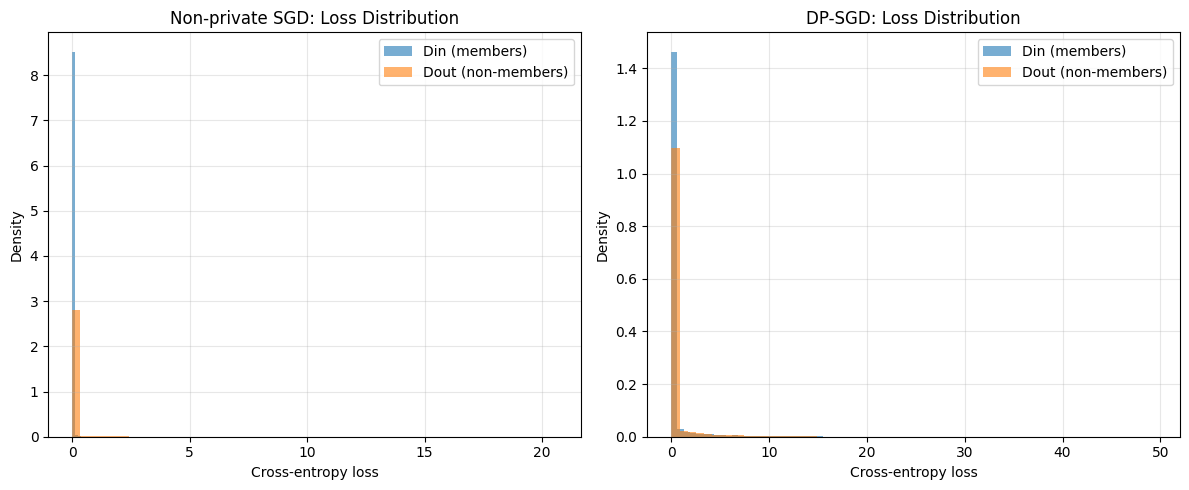

In [18]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(
    attack_df.loc[attack_df["true_membership"] == 1, "nonprivate_loss"],
    bins=60,
    alpha=0.6,
    density=True,
    label="Din (members)"
)
plt.hist(
    attack_df.loc[attack_df["true_membership"] == 0, "nonprivate_loss"],
    bins=60,
    alpha=0.6,
    density=True,
    label="Dout (non-members)"
)
plt.xlabel("Cross-entropy loss")
plt.ylabel("Density")
plt.title("Non-private SGD: Loss Distribution")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(
    attack_df.loc[attack_df["true_membership"] == 1, "private_loss"],
    bins=60,
    alpha=0.6,
    density=True,
    label="Din (members)"
)
plt.hist(
    attack_df.loc[attack_df["true_membership"] == 0, "private_loss"],
    bins=60,
    alpha=0.6,
    density=True,
    label="Dout (non-members)"
)
plt.xlabel("Cross-entropy loss")
plt.ylabel("Density")
plt.title("DP-SGD: Loss Distribution")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Threshold Selection Strategy

The assignment asks us to choose the attack threshold $\tau$ ourselves. Rather than selecting $\tau$ arbitrarily, we choose it in a data-driven way using a **calibration split** constructed from member and non-member losses. 

More precisely, we first separate the available loss values into:

- a **calibration set**, used only to choose $\tau$
- an **evaluation set**, used only for final attack reporting

This separation is important because choosing the threshold and evaluating the same attack on the same data can make the results look overly optimistic.

We sweep candidate thresholds and choose the one that maximizes **Youden's statistic**

$$
J(\tau) = \mathrm{TPR}(\tau) - \mathrm{FPR}(\tau).
$$

Here,

$$
\mathrm{TPR} = \frac{TP}{TP + FN}, \qquad
\mathrm{FPR} = \frac{FP}{FP + TN}.
$$

Maximizing $J$ selects a threshold that balances true-member detection against false alarms. After fixing $\tau$ on the calibration split, we evaluate the final confusion matrix on the disjoint evaluation split.

## Choosing the Threshold $ (\tau) $ using a Calibration Split

The assignment allows us to choose the threshold $ \tau $ ourselves.

To avoid choosing $ \tau $ and evaluating the attack on exactly the same samples, we use a simple **calibration/evaluation split** for each model:

- a **calibration split**, used only to choose $ \tau $
- an **evaluation split**, used only to report the final confusion matrix

We choose $ \tau $ on the calibration split by maximizing **Youden's $ J $ statistic**:

$$
J(\tau) = \mathrm{TPR}(\tau) - \mathrm{FPR}(\tau).
$$

Here,

$$
\mathrm{TPR} = \frac{TP}{TP+FN}, \qquad
\mathrm{FPR} = \frac{FP}{FP+TN}.
$$

This gives a threshold that tries to balance correctly identifying members against falsely declaring non-members as members.

After selecting $ \tau $ on the calibration split, we report the **final confusion matrix only on the disjoint evaluation split**.

For the **ROC curve and AUC**, we use the full member/non-member loss sets, since ROC/AUC are threshold-free summaries of attack separability over all possible thresholds.

In [19]:
def split_member_nonmember_losses(member_losses, nonmember_losses, seed=SEED, calib_fraction=0.5):
    rng = np.random.default_rng(seed)

    member_losses = np.asarray(member_losses)
    nonmember_losses = np.asarray(nonmember_losses)

    member_perm = rng.permutation(len(member_losses))
    nonmember_perm = rng.permutation(len(nonmember_losses))

    member_losses = member_losses[member_perm]
    nonmember_losses = nonmember_losses[nonmember_perm]

    m_calib = int(calib_fraction * len(member_losses))
    n_calib = int(calib_fraction * len(nonmember_losses))

    return {
        "member_calib": member_losses[:m_calib],
        "member_eval": member_losses[m_calib:],
        "nonmember_calib": nonmember_losses[:n_calib],
        "nonmember_eval": nonmember_losses[n_calib:],
    }


def get_candidate_thresholds(member_losses, nonmember_losses):
    all_losses = np.unique(np.concatenate([member_losses, nonmember_losses]))

    if len(all_losses) == 1:
        eps = 1e-8
        return np.array([all_losses[0] - eps, all_losses[0] + eps])

    mids = (all_losses[:-1] + all_losses[1:]) / 2.0
    eps = 1e-8

    thresholds = np.concatenate([
        [all_losses[0] - eps],
        mids,
        [all_losses[-1] + eps],
    ])
    return thresholds


def sweep_thresholds(member_losses, nonmember_losses):
    member_losses = np.asarray(member_losses)
    nonmember_losses = np.asarray(nonmember_losses)

    thresholds = get_candidate_thresholds(member_losses, nonmember_losses)

    rows = []
    num_members = len(member_losses)
    num_nonmembers = len(nonmember_losses)

    for tau in thresholds:
        tp = int(np.sum(member_losses < tau))
        fn = int(num_members - tp)
        fp = int(np.sum(nonmember_losses < tau))
        tn = int(num_nonmembers - fp)

        tpr = tp / num_members if num_members > 0 else 0.0
        fpr = fp / num_nonmembers if num_nonmembers > 0 else 0.0
        tnr = tn / num_nonmembers if num_nonmembers > 0 else 0.0
        balanced_accuracy = 0.5 * (tpr + tnr)
        youdens_j = tpr - fpr

        rows.append({
            "threshold": float(tau),
            "TP": tp,
            "FN": fn,
            "FP": fp,
            "TN": tn,
            "TPR": tpr,
            "FPR": fpr,
            "TNR": tnr,
            "balanced_accuracy": balanced_accuracy,
            "youdens_j": youdens_j,
        })

    return pd.DataFrame(rows)


def choose_tau_from_calibration(member_losses_calib, nonmember_losses_calib):
    calib_curve_df = sweep_thresholds(member_losses_calib, nonmember_losses_calib)

    best_row = calib_curve_df.sort_values(
        by=["youdens_j", "balanced_accuracy", "threshold"],
        ascending=[False, False, True]
    ).iloc[0]

    return float(best_row["threshold"]), calib_curve_df


def evaluate_attack_at_tau(member_losses_eval, nonmember_losses_eval, tau):
    member_losses_eval = np.asarray(member_losses_eval)
    nonmember_losses_eval = np.asarray(nonmember_losses_eval)

    tp = int(np.sum(member_losses_eval < tau))
    fn = int(len(member_losses_eval) - tp)
    fp = int(np.sum(nonmember_losses_eval < tau))
    tn = int(len(nonmember_losses_eval) - fp)

    tpr = tp / len(member_losses_eval) if len(member_losses_eval) > 0 else 0.0
    fpr = fp / len(nonmember_losses_eval) if len(nonmember_losses_eval) > 0 else 0.0
    tnr = tn / len(nonmember_losses_eval) if len(nonmember_losses_eval) > 0 else 0.0
    balanced_accuracy = 0.5 * (tpr + tnr)
    youdens_j = tpr - fpr

    return {
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
        "TPR": tpr,
        "FPR": fpr,
        "TNR": tnr,
        "balanced_accuracy": balanced_accuracy,
        "youdens_j": youdens_j,
        "threshold": float(tau),
    }


def build_roc_and_auc(member_losses_eval, nonmember_losses_eval):
    roc_df = sweep_thresholds(member_losses_eval, nonmember_losses_eval)

    roc_df = roc_df.sort_values(["FPR", "TPR"]).reset_index(drop=True)
    roc_df = roc_df.drop_duplicates(subset=["FPR", "TPR"])

    auc_value = np.trapezoid(
        roc_df["TPR"].to_numpy(),
        roc_df["FPR"].to_numpy()
    )

    return roc_df, auc_value


def confusion_matrix_dataframe(cm_dict):
    return pd.DataFrame(
        [
            [cm_dict["TP"], cm_dict["FN"]],
            [cm_dict["FP"], cm_dict["TN"]],
        ],
        index=["Member (Truth)", "Not-Member (Truth)"],
        columns=["Member (Predicted)", "Not-Member (Predicted)"],
    )

In [20]:
nonprivate_member_losses = attack_df.loc[
    attack_df["true_membership"] == 1, "nonprivate_loss"
].to_numpy()
nonprivate_nonmember_losses = attack_df.loc[
    attack_df["true_membership"] == 0, "nonprivate_loss"
].to_numpy()

private_member_losses = attack_df.loc[
    attack_df["true_membership"] == 1, "private_loss"
].to_numpy()
private_nonmember_losses = attack_df.loc[
    attack_df["true_membership"] == 0, "private_loss"
].to_numpy()

# Split into calibration / evaluation only for selecting tau
nonprivate_split = split_member_nonmember_losses(
    nonprivate_member_losses,
    nonprivate_nonmember_losses,
    seed=SEED,
    calib_fraction=0.5,
)

private_split = split_member_nonmember_losses(
    private_member_losses,
    private_nonmember_losses,
    seed=SEED,
    calib_fraction=0.5,
)

# Choose tau using the calibration split
nonprivate_tau, nonprivate_calib_curve_df = choose_tau_from_calibration(
    nonprivate_split["member_calib"],
    nonprivate_split["nonmember_calib"],
)

private_tau, private_calib_curve_df = choose_tau_from_calibration(
    private_split["member_calib"],
    private_split["nonmember_calib"],
)

# Optional: evaluation-split confusion matrices (kept for reference)
nonprivate_cm_eval = evaluate_attack_at_tau(
    nonprivate_split["member_eval"],
    nonprivate_split["nonmember_eval"],
    nonprivate_tau,
)

private_cm_eval = evaluate_attack_at_tau(
    private_split["member_eval"],
    private_split["nonmember_eval"],
    private_tau,
)

# REQUIRED FOR REPORTING: confusion matrices on the full attack dataset
nonprivate_cm_full = evaluate_attack_at_tau(
    nonprivate_member_losses,
    nonprivate_nonmember_losses,
    nonprivate_tau,
)

private_cm_full = evaluate_attack_at_tau(
    private_member_losses,
    private_nonmember_losses,
    private_tau,
)

# ROC and AUC on the full attack dataset
nonprivate_curve_df, nonprivate_auc = build_roc_and_auc(
    nonprivate_member_losses,
    nonprivate_nonmember_losses,
)

private_curve_df, private_auc = build_roc_and_auc(
    private_member_losses,
    private_nonmember_losses,
)

print("Chosen tau for non-private model (from calibration split):", nonprivate_tau)
print("Chosen tau for private model (from calibration split):", private_tau)
print("AUC (non-private, full dataset):", nonprivate_auc)
print("AUC (private, full dataset):", private_auc)

Chosen tau for non-private model (from calibration split): 0.05528873763978481
Chosen tau for private model (from calibration split): 0.16730491816997528
AUC (non-private, full dataset): 0.511199476111111
AUC (private, full dataset): 0.5032417783333333


In [21]:
tau_summary_df = pd.DataFrame([
    {
        "model": "Non-private SGD",
        "tau_from_calibration": nonprivate_tau,
        "best_calibration_youdens_j": nonprivate_calib_curve_df["youdens_j"].max(),
        "best_calibration_balanced_accuracy": nonprivate_calib_curve_df["balanced_accuracy"].max(),
        "AUC_full_dataset": nonprivate_auc,
    },
    {
        "model": "DP-SGD",
        "tau_from_calibration": private_tau,
        "best_calibration_youdens_j": private_calib_curve_df["youdens_j"].max(),
        "best_calibration_balanced_accuracy": private_calib_curve_df["balanced_accuracy"].max(),
        "AUC_full_dataset": private_auc,
    },
])

display(tau_summary_df)

,model,tau_from_calibration,best_calibration_youdens_j,best_calibration_balanced_accuracy,AUC_full_dataset
0,Non-private SGD,0.055289,0.046533,0.523267,0.511199
1,DP-SGD,0.167305,0.018000,0.509000,0.503242


## Confusion Matrix Interpretation

After fixing the threshold $\tau$, each sample is classified as either **Member** or **Not-Member** according to whether its loss is below the threshold. The resulting confusion matrix is interpreted as follows: 

| Truth / Prediction | Member | Not-Member |
|---|---:|---:|
| Member | TP | FN |
| Not-Member | FP | TN |

Thus:

- **TP**: true members correctly identified as members
- **FN**: true members incorrectly classified as non-members
- **FP**: non-members incorrectly classified as members
- **TN**: non-members correctly identified as non-members

A stronger attack should ideally yield high $TPR$ and low $FPR$, i.e., many true members detected with few non-members falsely flagged.

## Confusion Matrices for the Loss-Based Attack

Using the threshold $ \tau $ chosen on the calibration split, we now evaluate the attack on the **held-out evaluation split**.

This is the fairest way to report the threshold-based attack, because the same samples are not being used both to tune the threshold and to judge its final performance.

## Final Confusion Matrices Reported for the Attack

We choose the threshold $ \tau $ using a calibration split of the member and non-member losses.  
After selecting $ \tau $, we report the final confusion matrices on the full attack dataset consisting of all samples from $ D_{\mathrm{in}} $ and $ D_{\mathrm{out}} $.

This keeps threshold selection principled while also matching the assignment requirement of reporting the attack performance on members and non-members drawn from $ D_{\mathrm{in}} $ and $ D_{\mathrm{out}} $.

In [22]:
print("Confusion matrix for Non-private SGD (full Din/Dout attack dataset):")
display(confusion_matrix_dataframe(nonprivate_cm_full))

print("Confusion matrix for DP-SGD (full Din/Dout attack dataset):")
display(confusion_matrix_dataframe(private_cm_full))

print("Optional reference: confusion matrix for Non-private SGD (evaluation split only):")
display(confusion_matrix_dataframe(nonprivate_cm_eval))

print("Optional reference: confusion matrix for DP-SGD (evaluation split only):")
display(confusion_matrix_dataframe(private_cm_eval))

Confusion matrix for Non-private SGD (full Din/Dout attack dataset):


,Member (Predicted),Not-Member (Predicted)
Member (Truth),29455,545
Not-Member (Truth),28091,1909


Confusion matrix for DP-SGD (full Din/Dout attack dataset):


,Member (Predicted),Not-Member (Predicted)
Member (Truth),26185,3815
Not-Member (Truth),25862,4138


Optional reference: confusion matrix for Non-private SGD (evaluation split only):


,Member (Predicted),Not-Member (Predicted)
Member (Truth),14732,268
Not-Member (Truth),14066,934


Optional reference: confusion matrix for DP-SGD (evaluation split only):


,Member (Predicted),Not-Member (Predicted)
Member (Truth),13037,1963
Not-Member (Truth),12984,2016


In [23]:
summary_attack_df = pd.DataFrame([
    {
        "model": "Non-private SGD",
        "chosen_tau": nonprivate_tau,
        "AUC": nonprivate_auc,
        "TP": nonprivate_cm_full["TP"],
        "FN": nonprivate_cm_full["FN"],
        "FP": nonprivate_cm_full["FP"],
        "TN": nonprivate_cm_full["TN"],
        "TPR": nonprivate_cm_full["TPR"],
        "FPR": nonprivate_cm_full["FPR"],
        "balanced_accuracy": nonprivate_cm_full["balanced_accuracy"],
    },
    {
        "model": "DP-SGD",
        "chosen_tau": private_tau,
        "AUC": private_auc,
        "TP": private_cm_full["TP"],
        "FN": private_cm_full["FN"],
        "FP": private_cm_full["FP"],
        "TN": private_cm_full["TN"],
        "TPR": private_cm_full["TPR"],
        "FPR": private_cm_full["FPR"],
        "balanced_accuracy": private_cm_full["balanced_accuracy"],
    },
])

display(summary_attack_df)

,model,chosen_tau,AUC,TP,FN,FP,TN,TPR,FPR,balanced_accuracy
0,Non-private SGD,0.055289,0.511199,29455,545,28091,1909,0.981833,0.936367,0.522733
1,DP-SGD,0.167305,0.503242,26185,3815,25862,4138,0.872833,0.862067,0.505383


## Sample-Level Attack Inspection

In addition to aggregate metrics, we also inspect 10 randomly selected samples:

- 5 members from $D_{\mathrm{in}}$
- 5 non-members from $D_{\mathrm{out}}$

For each selected image, we report:

- image index
- true membership status
- loss under the non-private model
- loss under the private model
- predicted membership status under both models

This qualitative inspection helps verify that the threshold-based rule is behaving as expected at the level of individual examples, and it directly matches the reporting requirement in the assignment.

## Report for 10 Randomly Selected Samples

We now select:

- 5 random samples from `Din` (members)
- 5 random samples from `Dout` (non-members)

For each sample, we report:

- image
- original MNIST index
- true status
- loss under both models
- attack prediction under both models

In [24]:
rng = np.random.default_rng(SEED)

member_local_indices = rng.choice(len(din_dataset), size=5, replace=False)
nonmember_local_indices = rng.choice(len(dout_dataset), size=5, replace=False)

selected_samples = []

for local_idx in member_local_indices:
    x, y, original_idx = din_dataset[int(local_idx)]
    selected_samples.append({
        "image": x,
        "label": int(y),
        "original_index": int(original_idx),
        "true_status": "Member",
    })

for local_idx in nonmember_local_indices:
    x, y, original_idx = dout_dataset[int(local_idx)]
    selected_samples.append({
        "image": x,
        "label": int(y),
        "original_index": int(original_idx),
        "true_status": "Not-Member",
    })

In [25]:
attack_df["nonprivate_attack_prediction"] = np.where(
    attack_df["nonprivate_loss"] < nonprivate_tau,
    "Member",
    "Not-Member",
)

attack_df["private_attack_prediction"] = np.where(
    attack_df["private_loss"] < private_tau,
    "Member",
    "Not-Member",
)

sample_rows = []

for item in selected_samples:
    original_idx = item["original_index"]
    row = attack_df.loc[attack_df["original_index"] == original_idx].iloc[0]

    sample_rows.append({
        "original_index": original_idx,
        "true_label": item["label"],
        "true_status": item["true_status"],
        "nonprivate_loss": row["nonprivate_loss"],
        "nonprivate_prediction": row["nonprivate_attack_prediction"],
        "private_loss": row["private_loss"],
        "private_prediction": row["private_attack_prediction"],
    })

sample_report_df = pd.DataFrame(sample_rows)
display(sample_report_df)

,original_index,true_label,true_status,nonprivate_loss,nonprivate_prediction,private_loss,private_prediction
0,25122,2,Member,1.617196e-03,Member,2.384186e-07,Member
1,44252,7,Member,4.768370e-07,Member,5.495397e-05,Member
2,54993,9,Member,1.453431e-02,Member,1.397864e+00,Not-Member
3,54702,9,Member,7.639588e-04,Member,2.466238e-01,Not-Member
4,2637,6,Member,1.668929e-06,Member,9.536739e-07,Member
5,59493,6,Not-Member,-0.000000e+00,Member,-0.000000e+00,Member
6,19076,4,Not-Member,2.182723e-02,Member,4.696736e-05,Member
7,51583,7,Not-Member,3.576278e-07,Member,4.768370e-07,Member
8,7855,0,Not-Member,3.576278e-07,Member,-0.000000e+00,Member
9,28566,2,Not-Member,-0.000000e+00,Member,-0.000000e+00,Member


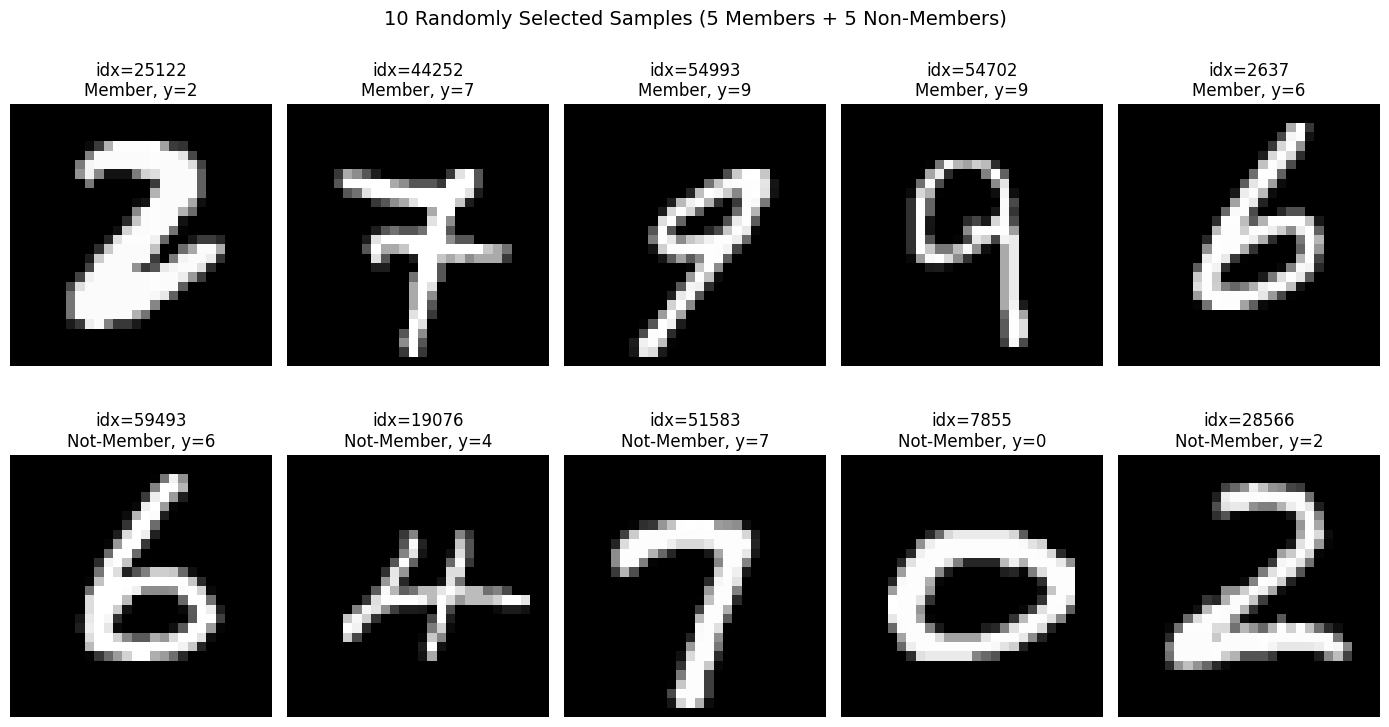

In [26]:
def unnormalize_mnist(x):
    return x * 0.3081 + 0.1307


fig, axes = plt.subplots(2, 5, figsize=(14, 8))
axes = axes.flatten()

for ax, item in zip(axes, selected_samples):
    img = item["image"].squeeze().cpu().numpy()
    img = unnormalize_mnist(img)

    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"idx={item['original_index']}\n"
        f"{item['true_status']}, y={item['label']}"
    )
    ax.axis("off")

plt.suptitle("10 Randomly Selected Samples (5 Members + 5 Non-Members)", fontsize=14)
plt.tight_layout()
plt.show()

## ROC Curve and AUC

The confusion matrix depends on a single threshold $\tau$, but the ROC curve evaluates the attack across **all possible thresholds**. For each threshold, we compute

$$
\mathrm{TPR}(\tau) = \frac{TP}{TP + FN}
= \Pr(\hat{x}=\mathrm{Member} \mid x \in D_{\mathrm{in}}),
$$

and

$$
\mathrm{FPR}(\tau) = \frac{FP}{FP + TN}
= \Pr(\hat{x}=\mathrm{Member} \mid x \in D_{\mathrm{out}}).
$$

Plotting $\mathrm{TPR}(\tau)$ against $\mathrm{FPR}(\tau)$ gives the **ROC curve**, as required in the assignment.

The **Area Under the Curve (AUC)** summarizes this ROC curve into a single number:

- $\mathrm{AUC} = 1$ corresponds to a perfect attack
- $\mathrm{AUC} = 0.5$ corresponds to random guessing
- larger AUC indicates stronger separation between members and non-members

AUC is a good metric here because it is **threshold-independent**: instead of judging the attack at one arbitrarily chosen threshold, it evaluates the attacker’s ranking ability over the full range of thresholds. Hence it provides a more robust measure of membership leakage than a single confusion matrix alone. This is why AUC is particularly appropriate for comparing the non-private and private models.

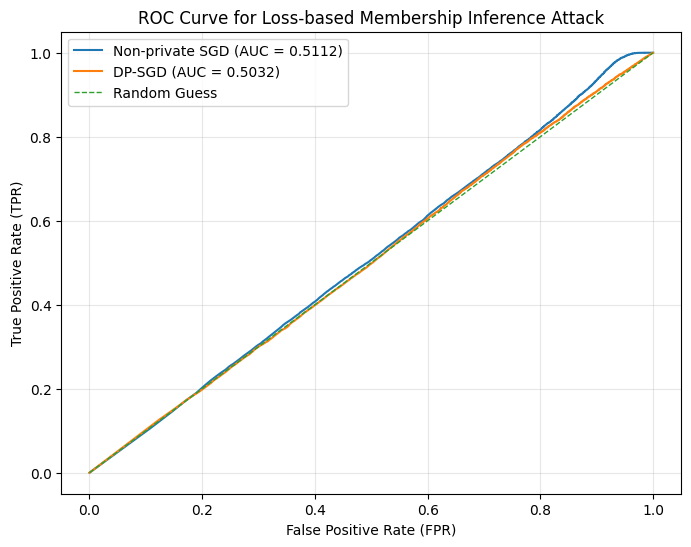

In [27]:
plt.figure(figsize=(8, 6))

plt.plot(
    nonprivate_curve_df["FPR"],
    nonprivate_curve_df["TPR"],
    label=f"Non-private SGD (AUC = {nonprivate_auc:.4f})",
)

plt.plot(
    private_curve_df["FPR"],
    private_curve_df["TPR"],
    label=f"DP-SGD (AUC = {private_auc:.4f})",
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Guess")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve for Loss-based Membership Inference Attack")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Discussion and Conclusion

The loss-based membership inference attack relies on the intuition that training samples often receive lower loss than unseen samples. If a model memorizes its training data more strongly, then the member and non-member loss distributions become easier to separate, making the attack more effective.

In our experiment, the **non-private SGD model** has a slightly larger AUC than the **DP-SGD model**, so it is empirically **more vulnerable** to this attack. This matches the expected role of differential privacy: DP-SGD reduces the influence of any single training example on the learned model, thereby weakening sample-specific leakage.

However, the **absolute AUC values are both very close to $0.5$**, which means that the loss-based attack is only **slightly better than random guessing** for both models. Hence, the correct interpretation is not only that the non-private model is relatively more vulnerable, but also that **the attack itself is weak in absolute terms** in this experimental setting.

The confusion matrices should also be interpreted together with the AUC values. If the chosen threshold produces a high false-positive rate, that indicates that the member and non-member loss distributions overlap substantially, so no single threshold cleanly separates the two groups.

Overall, the empirical result supports the expected privacy intuition: **the non-private model is somewhat more vulnerable to membership inference, while DP-SGD reduces this vulnerability**, although in this experiment the attack remains weak for both models.

## Conclusion

In this notebook, we implemented a simple **loss-based Membership Inference Attack (MIA)** on MNIST.

We:

1. split the data into $D_{\mathrm{in}}$ and $D_{\mathrm{out}}$
2. trained a non-private SGD model and a DP-SGD model on $D_{\mathrm{in}}$
3. computed per-sample cross-entropy losses on both $D_{\mathrm{in}}$ and $D_{\mathrm{out}}$
4. selected an attack threshold $ \tau $ using a calibration split
5. reported confusion matrices on a disjoint evaluation split
6. plotted ROC curves and computed AUC for both models

AUC is a good metric here because it evaluates the attack over **all possible thresholds**, rather than depending on one specific choice of $ \tau $. Thus, it measures how well member and non-member losses are separated overall.

The model with the **higher AUC** is more vulnerable to membership inference. In our experiment, the **non-private SGD model** is slightly more vulnerable than the **DP-SGD model**, but both AUC values are close to $0.5$, indicating that the attack is weak overall.

In [28]:
more_vulnerable = "Non-private SGD" if nonprivate_auc > private_auc else "DP-SGD"

print(f"AUC of Non-private SGD: {nonprivate_auc:.6f}")
print(f"AUC of DP-SGD: {private_auc:.6f}")
print(f"More vulnerable model according to AUC: {more_vulnerable}")

print("\nWhy AUC is a good metric here:")
print("- AUC evaluates the attack over all possible thresholds tau, rather than depending on one specific threshold.")
print("- It measures how well member samples are separated from non-member samples based on loss.")
print("- A higher AUC indicates that the attacker can distinguish training points from holdout points more effectively.")

if nonprivate_auc > private_auc:
    print("\nConclusion: the non-private model is more vulnerable to membership inference than the DP-SGD model.")
elif private_auc > nonprivate_auc:
    print("\nConclusion: the DP-SGD model appears more vulnerable in this experiment.")
else:
    print("\nConclusion: both models have essentially the same vulnerability in this experiment.")

AUC of Non-private SGD: 0.511199
AUC of DP-SGD: 0.503242
More vulnerable model according to AUC: Non-private SGD

Why AUC is a good metric here:
- AUC evaluates the attack over all possible thresholds tau, rather than depending on one specific threshold.
- It measures how well member samples are separated from non-member samples based on loss.
- A higher AUC indicates that the attacker can distinguish training points from holdout points more effectively.

Conclusion: the non-private model is more vulnerable to membership inference than the DP-SGD model.
